Tested with:
- Python 3.13.9
- numpy 2.4.4
- pandas 2.3.3
- scikit-learn 1.7.2
- rdkit 2026.3.1
- modAL 0.4.2.1
- schnetpack 2.2.0
- ase 3.26.0
- torch 2.6.0+cu124
- torch_geometric 2.7.0
- scikit-activeml 1.0.0
- skorch 1.3.1

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pprint  # Pretty print data structures
import os
import copy
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
import sklearn
import skorch
import torch
import random
import joblib
import skactiveml
from rdkit import Chem
from sklearn.base import clone
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_squared_error
import torch.nn.functional as F

plt.style.use('ggplot')  # Set Matplotlib style to 'ggplot'

# Set seed for reproducibility

os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
def seed_set(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_set(42)
torch.use_deterministic_algorithms(True)
generator = torch.Generator().manual_seed(42)

In [2]:
# --- Training and Evaluation Functions ---
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
target_idx = 4 # 'gap' in list ['mu', 'alpha', 'homo', 'lumo', 'gap', 'zpve', 'u0', 'u298', 'h298', 'g298', 'cv']

def train(loader, model):
    '''
    Train the model for one epoch on loader.

    Optimizes using MSE loss, and reports RMSE, MAE, and MSE
    
    Args:
        loader: Data loader yielding batched graph data.
        model: Model that takes `(data.z, data.pos, data.batch)` as input.

    Returns: 
        tuple: `(rmse, mae, mse, r2)` for the epoch, or
        `(nan, nan, nan, nan)` if no valid samples are processed.
    '''
    model.train()
    total_loss = total_mae = total_samples = 0
    y_pred, y_true = [], []
    for data in loader:
        data = data.to(device)
        true = data.y.view(data.num_graphs, -1)[:, target_idx]
        if torch.isnan(true).any() or torch.isinf(true).any():
            continue
        
        pred = model(data.z, data.pos, data.batch).squeeze(-1)
        if torch.isnan(pred).any() or torch.isinf(pred).any():
            continue
        
        optimizer.zero_grad()
        mse_loss = F.mse_loss(pred, true)
        mae_loss = F.l1_loss(pred, true)
        mse_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += mse_loss.item() * data.num_graphs
        total_mae += mae_loss.item() * data.num_graphs
        total_samples += data.num_graphs
        
        y_pred.append(pred.detach().cpu())
        y_true.append(true.detach().cpu())
    y_pred = torch.cat(y_pred).numpy()
    y_true = torch.cat(y_true).numpy()
    
    if total_samples == 0:
        return float('nan'), float('nan'), float('nan'), float('nan')
    
    rmse = np.sqrt(total_loss/total_samples)
    mae = total_mae/total_samples
    mse = total_loss/total_samples
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, mse, r2

@torch.no_grad()
def evaluate(loader, model):
    '''
    Evaluate model on loader and compute regression metrics.

    Args:
        loader: Data loader yielding batched graph data.
        model: Model that takes `(data.z, data.pos, data.batch)` as input.

    Returns:
        tuple: `(rmse, mae, mse, r2, y_true, y_pred)`, where `y_true` and
        `y_pred` are NumPy arrays containing the true and predicted values.
    '''
    model.eval()
    y_pred, y_true = [], []
    for data in loader:
        data = data.to(device)
        true = data.y.view(data.num_graphs, -1)[:, target_idx]
        pred = model(data.z, data.pos, data.batch).squeeze(-1)
        y_pred.append(pred.cpu().numpy())
        y_true.append(true.cpu().numpy())
    y_pred = np.concatenate(y_pred)
    y_true = np.concatenate(y_true)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, mse, r2, y_true, y_pred

@torch.no_grad()
def plot_prediction(loader, model, model_name=None, name='gap', figsize=(6, 6), save=None, format='pdf'):
    '''
    Plot predicted vs. true values for model on loader.

    Computes evaluation metrics, displays a scatter plot of true versus
    predicted values with a reference diagonal, and prints MAE, MSE, RMSE,
    and R^2.

    Args:
        loader: Data loader yielding batched graph data (torch_geometric.loader.DataLoader).
        model: Fitted model (torch compatible model).
        model_name: Name of the model (str).
        name: Name of the target value (str). 
        figsize: Figure size (tuple).
        save: Save path (str).
        format: Save format (str).
    '''
    rmse, mae, mse, r2, y_true, y_pred = evaluate(loader, model)
    errors = np.abs(y_true - y_pred)/y_true
    norm = colors.Normalize(vmin=0.0, vmax=1.0, clip=True)
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(y_true, y_pred, c=errors, cmap='viridis', norm=norm, label='predicted values')
    ax.plot(y_true, y_true, 'r-', label='ideal')
    ax.set_xlabel(f'true {name}', fontsize=14)
    ax.set_ylabel(f'predicted {name}', fontsize=14)
    ax.legend(facecolor='white', fontsize=14)
    if model_name is None:
        ax.set_title(f'{name} {model.__class__.__name__} prediction plot')
    else:
        ax.set_title(f'{name} {model_name} prediction plot')
    
    if save is not None:
        fig.savefig(save, format=format, dpi=300)
    plt.show()
    print('Training scores:')
    print(f'MAE = {mae:.4f}')
    print(f'MSE = {mse:.4f}') 
    print(f'RMSE = {rmse:.4f}')
    print(f'r^2 = {r2:.4f}')

In [18]:
# Draw 3D structure of a molecule
import py3Dmol
from ase import Atoms
from ase.io import write
from io import StringIO


def show_ase_atoms_3d(atoms, width=500, height=400):
    buf = StringIO()
    write(buf, atoms, format='xyz')
    xyz = buf.getvalue()

    view = py3Dmol.view(width=width, height=height)
    view.addModel(xyz, 'xyz')
    view.setStyle(
        {
            'stick': {'radius': 0.15},
            'sphere': {'scale': 0.28},
        }
    )
    view.zoomTo()
    return view.show()

dataset = torch.load('../data/qm9/qm9.pt', weights_only=False)
entry = dataset[4809]
atoms = Atoms(numbers=entry.z, positions=entry.pos)
show_ase_atoms_3d(atoms)
print(f'gap = {entry.y[4]:.4f} Ha')

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

gap = 0.2199 Ha


### Load dataset

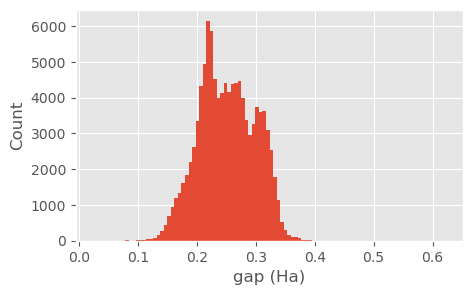

Min gap: 0.0246 Ha
Max gap: 0.6221 Ha


In [46]:
# Plot train histogram
train_gaps = np.array(
    [float(data.y.detach().cpu().view(-1)[target_idx]) for data in train_data],
    dtype=float,
)
plt.figure(figsize=(5, 3))
plt.hist(train_gaps, bins=100)
plt.xlabel('gap (Ha)')
plt.ylabel('Count')
plt.show()
print(f'Min gap: {train_gaps.min():.4f} Ha')
print(f'Max gap: {train_gaps.max():.4f} Ha')

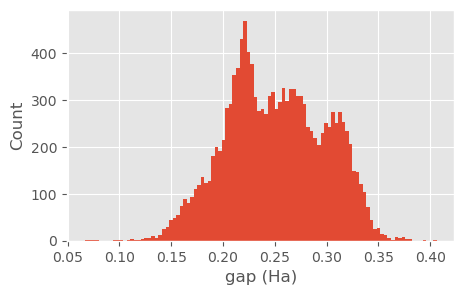

Min gap: 0.0663 Ha
Max gap: 0.4063 Ha


In [47]:
# Plot test histogram
test_gaps = np.array(
    [float(data.y.detach().cpu().view(-1)[target_idx]) for data in test_data],
    dtype=float,
)
plt.figure(figsize=(5, 3))
plt.hist(test_gaps, bins=100)
plt.xlabel('gap (Ha)')
plt.ylabel('Count')
plt.show()
print(f'Min gap: {test_gaps.min():.4f} Ha')
print(f'Max gap: {test_gaps.max():.4f} Ha')

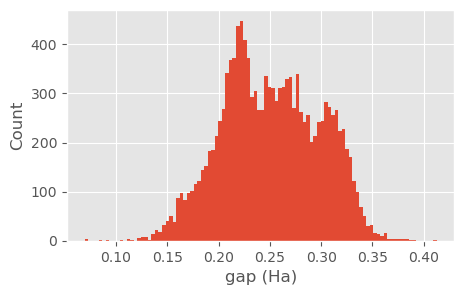

Min gap: 0.0692 Ha
Max gap: 0.4128 Ha


In [48]:
# Plot val histogram
val_gaps = np.array(
    [float(data.y.detach().cpu().view(-1)[target_idx]) for data in val_data],
    dtype=float,
)
plt.figure(figsize=(5, 3))
plt.hist(val_gaps, bins=100)
plt.xlabel('gap (Ha)')
plt.ylabel('Count')
plt.show()
print(f'Min gap: {val_gaps.min():.4f} Ha')
print(f'Max gap: {val_gaps.max():.4f} Ha')

In [3]:
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

train_dataset = torch.load('../data/qm9/gap/qm9_gap_train.pt', weights_only=False)
test_dataset = torch.load('../data/qm9/gap/qm9_gap_test.pt', weights_only=False)
val_dataset = torch.load('../data/qm9/gap/qm9_gap_val.pt', weights_only=False)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, generator=generator)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

In [14]:
print(train_dataset[0].z)

tensor([6, 6, 6, 6, 6, 6, 6, 6, 8, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [3]:
# --- DataLoaders(Sample) ---
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch.utils.data import Subset

train_dataset = torch.load('../data/qm9/gap/qm9_gap_train.pt', weights_only=False)
test_dataset = torch.load('../data/qm9/gap/qm9_gap_test.pt', weights_only=False)
val_dataset = torch.load('../data/qm9/gap/qm9_gap_val.pt', weights_only=False)

sample_ratio = 0.1
rng = np.random.default_rng(42)

train_n = max(1, int(len(train_dataset) * sample_ratio))
val_n = max(1, int(len(val_dataset) * sample_ratio))
test_n = max(1, int(len(test_dataset) * sample_ratio))

train_idx = rng.choice(len(train_dataset), size=train_n, replace=False)
val_idx = rng.choice(len(val_dataset), size=val_n, replace=False)
test_idx = rng.choice(len(test_dataset), size=test_n, replace=False)

train_dataset = [train_dataset[i] for i in train_idx]
val_dataset = [val_dataset[i] for i in val_idx]
test_dataset = [test_dataset[i] for i in test_idx]

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=generator)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Baseline

## Schnet

### Training

In [5]:
from torch_geometric.nn import SchNet
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Create a config dictionary
config = {
    'hidden_channels': 64,
    'num_filters': 256,
    'num_interactions': 6,
    'num_gaussians': 50,
    'cutoff': 6.0,
    'target_idx': 4, # 'gap'
    'readout' : 'add',
}

# Define model
model = SchNet(
    hidden_channels=config['hidden_channels'],
    num_filters=config['num_filters'],
    num_interactions=config['num_interactions'],
    num_gaussians=config['num_gaussians'],
    cutoff=config['cutoff'],
    readout=config['readout'],
).to(device)

# Define optimizer
optimizer = Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

# Training Loop
epochs=500
counter=0
early_stopping=10

best_rmse = float('inf')
history = {'train_rmse': [], 'train_mae': [], 'train_mse': [], 'test_rmse': [], 'test_mae': [], 'test_mse': [], 'test_r2': []}

epoch_bar = tqdm(range(epochs), desc='Training', unit='epoch', ncols=150)
for epoch in epoch_bar:
    train_rmse, train_mae, train_mse, train_r2 = train(train_loader, model)
    test_rmse, test_mae, test_mse, test_r2, test_y_true, test_y_pred  = evaluate(test_loader, model)
    
    scheduler.step(test_mse)

    # Track history
    history['train_rmse'].append(train_rmse)
    history['train_mae'].append(train_mae)
    history['train_mse'].append(train_mse)
    history['test_rmse'].append(test_rmse)
    history['test_mae'].append(test_mae)
    history['test_mse'].append(test_mse)
    history['test_r2'].append(test_r2)

    # Save best model
    if test_rmse < best_rmse:
        best_rmse = test_rmse
        counter=0
        torch.save({
            'model_state_dict': model.state_dict(),
            'config': config
        }, 'models/schnet/schnet_gap_qm9_2.pt')
    else:
        counter+=1

    epoch_bar.set_postfix(
        train_rmse=f'{train_rmse:.4f}',
        test_rmse=f'{test_rmse:.4f}',
        best_rmse=f'{best_rmse:.4f}',
        lr=f'{optimizer.param_groups[0]['lr']:.1e}',
        paitence_counter=f'{counter}/{early_stopping}'
    )
    
    if counter >= early_stopping:
            print('Early stopping triggered.')
            break    
print(f'Best test RMSE: {best_rmse:.4f}')

df = pd.DataFrame(history)
df.to_csv('models/schnet/history_schnet_gap_qm9_2.csv', index=False)

Training: 100%|████| 500/500 [33:02:19<00:00, 237.88s/epoch, best_rmse=0.0059, lr=1.0e-06, paitence_counter=9/20, test_rmse=0.0060, train_rmse=0.0052]

Best test RMSE: 0.0059


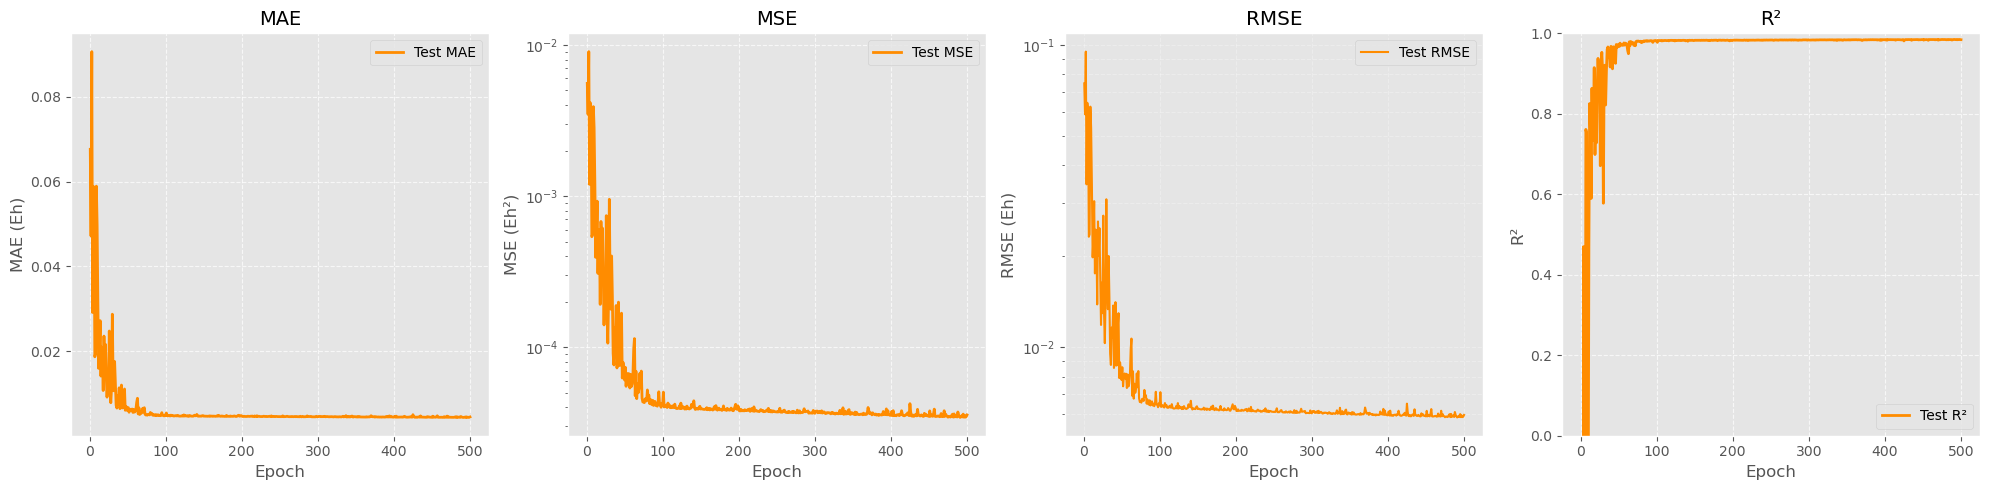

In [12]:
import matplotlib.pyplot as plt

def plot_history(history, save=None, format='pdf'):
    epochs = range(1, len(history['train_mae']) + 1)
    
    # Create a figure with two side-by-side plots
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 5))

    # --- Plot 1: MAE (Mean Absolute Error) ---
    ax1.plot(epochs, history['test_mae'], label='Test MAE', color='darkorange', lw=2)
    ax1.set_title('MAE', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('MAE (Eh)', fontsize=12)
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    # --- Plot 2: MSE (Mean Squared Error) ---
    ax2.semilogy(epochs, history['test_mse'], label='Test MSE', color='darkorange', lw=2)
    ax2.set_title('MSE', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('MSE (Eh²)', fontsize=12)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    # --- Plot 3: RMSE (Log Scale) ---
    ax3.semilogy(epochs, history['test_rmse'], label='Test RMSE', color='darkorange')
    ax3.set_title('RMSE')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('RMSE (Eh)')
    ax3.legend()
    ax3.grid(True, which='both', linestyle='--', alpha=0.3)

    # --- Plot 4: R2 ---
    ax4.plot(epochs, history['test_r2'], label='Test R²', color='darkorange', lw=2)
    ax4.set_title('R²', fontsize=14)
    ax4.set_xlabel('Epoch', fontsize=12)
    ax4.set_ylabel('R²', fontsize=12)
    ax4.set_ylim(0, 1)
    ax4.legend()
    ax4.grid(True, linestyle='--', alpha=0.7)


    plt.tight_layout()
    if save is not None:
        plt.savefig(save, format=format, dpi=300)
    plt.show()

df = pd.read_csv('models/schnet/history_schnet_gap_qm9_2.csv')
history = df.to_dict(orient='list')
plot_history(history, save='models/schnet/history_schnet_gap_qm9_2.png', format='png')

### Model evaluation
- schnet_gap_qm9_sample.pt: optimizer = Adam(model.parameters(), lr=1e-3) scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
- schnet_gap_qm9_0.pt: optimizer = Adam(model.parameters(), lr=1e-3) scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
- schnet_gap_qm9_1.pt: optimizer = Adam(model.parameters(), lr=1e-3) scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
- schnet_gap_qm9_2.pt: optimizer = Adam(model.parameters(), __lr=1e-4__) scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

In [14]:
#Load model
from torch_geometric.nn import SchNet

# Loading
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load('models/schnet/schnet_gap_qm9_2.pt', map_location=device)
conf = checkpoint['config']

# Automatically use the saved hyperparameters
model = SchNet(
    hidden_channels=conf['hidden_channels'],
    num_filters=conf['num_filters'],
    num_interactions=conf['num_interactions'],
    num_gaussians=conf['num_gaussians'],
    cutoff=conf['cutoff'],
    readout=conf.get('readout', 'add'),
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

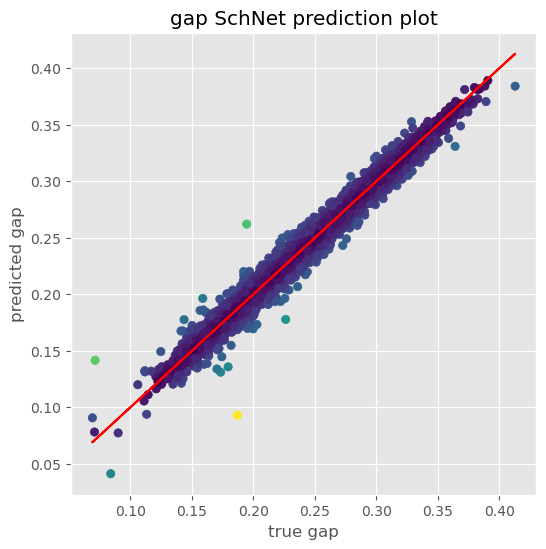

Training scores:
MAE = 0.0043
MSE = 0.0000
RMSE = 0.0059
r^2 = 0.9848


In [19]:
plot_prediction(val_loader, model, save='models/schnet/schnet_gap_qm9_plot_2.pdf')

# AL Query Strategies

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, Subset
from sklearn.model_selection import train_test_split

from torch_geometric.data import InMemoryDataset
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import SchNet

from skorch import NeuralNetRegressor
from skorch.helper import predefined_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from skorch.callbacks import LRScheduler, EarlyStopping, Checkpoint

class LoadedQM9(InMemoryDataset):
    """
    Use this if your .pt file contains (data, slices), which is the common
    PyG InMemoryDataset saved format.
    """

    def __init__(self, pt_path):
        super().__init__(root=".")
        self.data, self.slices = torch.load(pt_path, weights_only=False)


class QM9TargetDataset(Dataset):
    """
    Returns:
      X = PyG Data object
      y = scalar target tensor
    """

    def __init__(self, base_dataset, target_idx):
        self.base_dataset = base_dataset
        self.target_idx = target_idx

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        data = self.base_dataset[idx]

        # QM9 targets are often shaped [1, num_targets] per sample.
        y = data.y.view(-1, data.y.shape[-1])[0, self.target_idx].float()

        return data, y


class SchNetRegressorModule(nn.Module):
    def __init__(
        self,
        hidden_channels=128,
        num_filters=128,
        num_interactions=6,
        num_gaussians=50,
        cutoff=10.0,
    ):
        super().__init__()
        self.schnet = SchNet(
            hidden_channels=hidden_channels,
            num_filters=num_filters,
            num_interactions=num_interactions,
            num_gaussians=num_gaussians,
            cutoff=cutoff,
            readout="add",
        )

    def forward(self, data):
        # data is a PyG Batch object from torch_geometric.loader.DataLoader
        out = self.schnet(
            z=data.z,
            pos=data.pos,
            batch=data.batch,
        )

        # Make output shape [batch]
        return out.view(-1)

In [5]:
train_ds = QM9TargetDataset(train_dataset, target_idx=target_idx)
test_ds = QM9TargetDataset(test_dataset, target_idx=target_idx)

In [6]:
# ------------------------------------------------------------------
# 3) Skorch model
# ------------------------------------------------------------------

net = NeuralNetRegressor(
    module=SchNetRegressorModule,
    module__hidden_channels=64,
    module__num_filters=256,
    module__num_interactions=6,
    module__num_gaussians=50,
    module__cutoff=6.0,
    criterion=nn.MSELoss,
    optimizer=torch.optim.Adam,
    lr=1e-4,
    batch_size=32,
    max_epochs=100,
    iterator_train=PyGDataLoader,
    iterator_valid=PyGDataLoader,
    iterator_train__shuffle=True,
    iterator_train__num_workers=0,
    iterator_valid__num_workers=0,
    train_split=predefined_split(test_ds),
    device=device,
    verbose=1,  # Turn off standard epoch output prints from skorch
    callbacks=[
        ('lr_scheduler', LRScheduler(
            policy=ReduceLROnPlateau,
            monitor='valid_loss',  # Tracks validation MSE loss
            mode='min',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
        )),
        ('early_stopping', EarlyStopping(
            monitor='valid_loss',
            patience=10,
            lower_is_better=True,
            threshold=0.001,
            threshold_mode='rel',
        )),
        ('checkpoint', Checkpoint(
            f_params='models/schnet/skorch_schnet_gap_qm9_1.pt',
            f_history='models/schnet/history_skorch_schnet_gap_qm9_1.json',
            f_criterion=None,
            f_optimizer=None,
            monitor='valid_loss_best',
            load_best=True,
        )),
    ],
)

net.fit(train_ds, y=None)

  epoch    train_loss    valid_loss    cp      lr       dur
-------  ------------  ------------  ----  ------  --------
      1        0.0682        0.0138     +  0.0001  240.1790
      2        0.0046        0.0057     +  0.0001  240.4167
      3        0.0033        0.0114        0.0001  240.4029
      4        0.0020        0.0049     +  0.0001  240.3797
      5        0.0016        0.0009     +  0.0001  240.3985
      6        0.0013        0.0010        0.0001  240.2164
      7        0.0011        0.0014        0.0001  240.1707
      8        0.0009        0.0011        0.0001  240.2470
      9        0.0008        0.0011        0.0001  240.2486
     10        0.0007        0.0003     +  0.0001  240.0418
     11        0.0006        0.0009        0.0001  240.0094
     12        0.0006        0.0007        0.0001  240.1908
     13        0.0005        0.0006        0.0001  240.2386
     14        0.0005        0.0005        0.0001  240.2443
     15        0.0005        0.0004     

,module,<class '__mai...ressorModule'>
,criterion,<class 'torch...loss.MSELoss'>
,optimizer,<class 'torch...im.adam.Adam'>
,lr,0.0001
,max_epochs,100
,batch_size,32
,iterator_train,<class 'torch...r.DataLoader'>
,iterator_valid,<class 'torch...r.DataLoader'>
,dataset,<class 'skorc...aset.Dataset'>
,train_split,functools.par...7f6694423890>)
,callbacks,"[('lr_scheduler', ...), ('early_stopping', ...), ...]"


In [4]:
from skorch import NeuralNetRegressor
from skorch.dataset import Dataset
from skactiveml.pool import RandomSampling
from skactiveml.utils import MISSING_LABEL, labeled_indices, unlabeled_indices
import logging
logging.getLogger('skorch').setLevel(logging.WARNING)


# ── PyG Dataset-to-skorch Adapter ─────────────────────────────────────────────
class PyGDatasetWrapper(Dataset):
    '''
    Slightly modified skorch Dataset to handle PyTorch Geometric data objects.
    Skorch expects indexing to return input features 'X' and targets 'y'.
    '''

    def __init__(self, pyg_dataset):
        self.pyg_dataset = pyg_dataset

    def __len__(self):
        return len(self.pyg_dataset)

    def __getitem__(self, idx):
        # 1. Resolve index from the wrapper's array
        actual_idx = int(idx)

        # 2. Extract PyG object natively
        data = self.pyg_dataset[actual_idx]

        # 3. Extract the clean target tensor
        y_val = torch.tensor(
            [data.y.view(-1)[target_idx].item()], dtype=torch.float32
        )
        return data, y_val


# ── PyTorch Geometric-compatible Skorch Net ───────────────────────────────────
class PyGNeuralNetRegressor(NeuralNetRegressor):
    '''
    Custom skorch NeuralNetRegressor overriding the batch collation and step passes
    to properly handle PyTorch Geometric Graph DataLoader collations.
    '''

    def get_iterator(self, dataset, training=False, **kwargs):
        # Overridden to use PyG's DataLoader instead of standard PyTorch DataLoader
        return DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=training,
        )

    def train_step_single(self, batch, **fit_params):
        self.module_.train()
        self.optimizer_.zero_grad()

        # In get_iterator, dataset yields (data, y_target)
        # collated by PyG DataLoader: batch[0] is PyG Batch, batch[1] is target tensor
        data, y_true = batch
        data = data.to(self.device)
        y_true = y_true.to(self.device)

        # Forward pass matching your train() call: (z, pos, batch)
        y_pred = self.module_(data.z, data.pos, data.batch).squeeze(-1)

        loss = self.criterion_(y_pred, y_true)
        loss.backward()

        if hasattr(self, 'clip_grad_norm') and self.clip_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(
                self.module_.parameters(), max_norm=self.clip_grad_norm
            )

        self.optimizer_.step()
        return {'loss': loss, 'y_pred': y_pred}

    def validation_step(self, batch, **fit_params):
        self.module_.eval()
        data, y_true = batch
        data = data.to(self.device)
        y_true = y_true.to(self.device)

        with torch.no_grad():
            y_pred = self.module_(data.z, data.pos, data.batch).squeeze(-1)
            loss = self.criterion_(y_pred, y_true)

        return {'loss': loss, 'y_pred': y_pred}

    def evaluation_step(self, batch, training=False):
        # Overridden to ensure inference behaves consistently during predict() calls
        self.module_.eval()
        data, _ = batch
        data = data.to(self.device)
        with torch.no_grad():
            y_pred = self.module_(data.z, data.pos, data.batch).squeeze(-1)
        return y_pred

In [5]:
# ── Active Learning Loop Integration ──────────────────────────────────────────
def al_loop_rnd_skorch(
    skorch_model,
    n_initial=7106,
    batch_size=5000,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run an Active Learning loop with physical neural networks using skorch wrappers
    and skactiveml's native Query Strategies.
    '''
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)
    
    X_train_indices = np.arange(len(train_dataset)).reshape(-1, 1)
    
    X_train = PyGDatasetWrapper(train_dataset)
    X_val = PyGDatasetWrapper(val_dataset)
    X_test = PyGDatasetWrapper(test_dataset)

    y_val_true = np.array([val_dataset[i].y.view(-1)[target_idx].item() for i in range(len(val_dataset))]).flatten()
    y_test_true = np.array([test_dataset[i].y.view(-1)[target_idx].item() for i in range(len(test_dataset))]).flatten()
    y_train_all = np.array([train_dataset[i].y.view(-1)[target_idx].item() for i in range(len(train_dataset))]).flatten()
    
    all_histories = []

    for run in range(n_runs):
        run_seed = int(run_seeds[run])
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'=' * 60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'=' * 60}')

        # ── Label pool initialization ─────────────────────────────────────────
        y_pool = np.full(len(train_dataset), MISSING_LABEL)
        initial_idx = run_rng.choice(len(train_dataset), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train_all[initial_idx]

        # ── Query strategy ────────────────────────────────────────────────────
        rnd = RandomSampling(random_state=random_state)

        # ── History initialization ────────────────────────────────────────────
        history = {
            'run': [],
            'cycle': [],
            'n_labeled': [],
            'mae_test': [],
            'mse_test': [],
            'rmse_test': [],
            'r2_test': [],
            'mae_val': [],
            'mse_val': [],
            'rmse_val': [],
            'r2_val': [],
            'queried_idx': [],
        }

        # Clear PyTorch caching and create a clean clone of the wrapped model
        torch.cuda.empty_cache()
        reg = clone(skorch_model)

        if n_cycles is None:
            n_cycles = math.ceil((len(train_dataset) - n_initial) / batch_size) + 1

        # ── Active-learning loop ──────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_idx)

            # Subset the Skorch dataset using active label tracking
            X_train_subset_indices = X_train_indices[labeled_idx].flatten()
            y_train_subset = y_pool[labeled_idx]

            # 1. Train model utilizing skorch fit mechanics
            reg.fit(torch.utils.data.Subset(X_train, X_train_subset_indices), y_train_subset)

            # 2. Record predictions
            y_pred_test = reg.predict(X_test).flatten()
            y_pred_val = reg.predict(X_val).flatten()

            mae_test = mean_absolute_error(y_test_true, y_pred_test)
            mse_test = mean_squared_error(y_test_true, y_pred_test)
            rmse_test = root_mean_squared_error(y_test_true, y_pred_test)
            r2_test = r2_score(y_test_true, y_pred_test)

            mae_val = mean_absolute_error(y_val_true, y_pred_val)
            mse_val = mean_squared_error(y_val_true, y_pred_val)
            rmse_val = root_mean_squared_error(y_val_true, y_pred_val)
            r2_val = r2_score(y_val_true, y_pred_val)

            history['run'].append(run + 1)
            history['cycle'].append(cycle + 1)
            history['n_labeled'].append(n_labeled)
            history['mae_test'].append(mae_test)
            history['mse_test'].append(mse_test)
            history['rmse_test'].append(rmse_test)
            history['r2_test'].append(r2_test)
            history['mae_val'].append(mae_val)
            history['mse_val'].append(mse_val)
            history['rmse_val'].append(rmse_val)
            history['r2_val'].append(r2_val)

            if cycle == 0:
                history['queried_idx'].append(initial_idx.tolist())
            else:
                history['queried_idx'].append(query_idx.tolist())

            if len(unlabeled_idx) == 0:
                print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(train_dataset)} | '
                    f'MAE: {mae_test:.4f} eV | '
                    f'RMSE: {rmse_test:.4f} eV | '
                    f'R2: {r2_test:.4f} | '
                )
                print('All pool samples labeled.')
                break

            # 3. Query new samples using the skactiveml framework
            query_idx = rnd.query(
                X=X_train_indices,
                y=y_pool,
                batch_size=batch_size,
            )
            
            y_pool[query_idx] = y_train_all[query_idx]

            print(
                f'Cycle {cycle + 1:>2} | '
                f'Labeled: {n_labeled:>5}/{len(train_dataset)} | '
                f'MAE: {mae_test:.4f} Eh | '
                f'RMSE: {rmse_test:.4f} Eh | '
                f'R2: {r2_test:.4f} | '
            )

        print(
            f'\nDone. Final labeled count: {len(labeled_indices(y_pool))}/{len(train_dataset)}'
        )
        all_histories.append(history)

    df = pd.concat([pd.DataFrame(h) for h in all_histories], ignore_index=True)
    if save is not None:
        df.to_csv(save, index=False)

    return df

In [7]:
from torch_geometric.nn import SchNet
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from skorch.callbacks import LRScheduler, EarlyStopping, Checkpoint
from skorch.helper import predefined_split

config = {
    'hidden_channels': 64,
    'num_filters': 256,
    'num_interactions': 6,
    'num_gaussians': 50,
    'cutoff': 6.0,
    'target_idx': 4, # 'gap'
    'readout' : 'add',
}

skorch_schnet = PyGNeuralNetRegressor(
    module=SchNet,
    # Pass SchNet model parameters
    module__hidden_channels=config['hidden_channels'],
    module__num_filters=config['num_filters'],
    module__num_interactions=config['num_interactions'],
    module__num_gaussians=config['num_gaussians'],
    module__cutoff=config['cutoff'],
    module__readout=config['readout'],
    # Training Loop Configurations
    train_split=predefined_split(PyGDatasetWrapper(test_dataset)), # Validation on predefined test_dataset already contains y values
    criterion=torch.nn.MSELoss,
    optimizer=Adam,
    optimizer__lr=1e-4,
    max_epochs=100,
    batch_size=128,
    device=device,
    verbose=1,  # Turn off standard epoch output prints from skorch
    callbacks=[
        ('lr_scheduler', LRScheduler(
            policy=ReduceLROnPlateau,
            monitor='valid_loss',  # Tracks validation MSE loss
            mode='min',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
        )),
        ('early_stopping', EarlyStopping(
            monitor='valid_loss',
            patience=10,
            lower_is_better=True,
            threshold=0.001,
            threshold_mode='rel',
        )),
        ('checkpoint', Checkpoint(
            f_params='models/schnet/skorch_schnet_gap_qm9_0.pt',
            f_history='models/schnet/history_skorch_schnet_gap_qm9_0.json',
            monitor='valid_loss_best',
            load_best=True,
        )),
    ],
)

NameError: name 'PyGNeuralNetRegressor' is not defined

In [7]:
X_train = PyGDatasetWrapper(train_dataset)
y_train = np.array([train_dataset[i].y.view(-1)[target_idx].item() for i in range(len(train_dataset))]).flatten()
X_test = PyGDatasetWrapper(test_dataset)
y_test = np.array([test_dataset[i].y.view(-1)[target_idx].item() for i in range(len(test_dataset))]).flatten()

In [8]:
skorch_schnet.fit(X_train, y_train)

  epoch    train_loss    valid_loss    cp      lr       dur
-------  ------------  ------------  ----  ------  --------
      1        0.3472        0.0246     +  0.0001  227.0801
      2        0.0840        0.0353        0.0001  226.1888
      3        0.0421        0.0112     +  0.0001  226.1478
      4        0.0342        0.0235        0.0001  226.1467
      5        0.0253        0.0283        0.0001  226.3989
      6        0.0216        0.0306        0.0001  226.1230
      7        0.0155        0.0294        0.0001  226.1275
      8        0.0153        0.0036     +  0.0001  226.1147
      9        0.0114        0.0099        0.0001  226.3733
     10        0.0112        0.0091        0.0001  225.3080
     11        0.0096        0.0111        0.0001  223.9090
     12        0.0078        0.0073        0.0001  224.1044
     13        0.0075        0.0171        0.0001  223.9107
     14        0.0058        0.0025     +  0.0001  223.9249
     15        0.0045        0.0044     

,module,<class 'torch...chnet.SchNet'>
,criterion,<class 'torch...loss.MSELoss'>
,optimizer,<class 'torch...im.adam.Adam'>
,lr,0.01
,max_epochs,100
,batch_size,128
,iterator_train,<class 'torch...r.DataLoader'>
,iterator_valid,<class 'torch...r.DataLoader'>
,dataset,<class 'skorc...aset.Dataset'>
,train_split,functools.par...7fcd043667b0>)
,callbacks,"[('lr_scheduler', ...), ('early_stopping', ...), ...]"


In [20]:
torch.save({
            'model_state_dict': skorch_schnet.module_.state_dict(),
            'config': config
        }, 'models/schnet/skorch_schnet_gap_qm9_0.pt')

In [8]:
#Load model
from torch_geometric.nn import SchNet
from collections import OrderedDict

# Loading
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load('models/schnet/skorch_schnet_gap_qm9_1.pt', map_location=device)
new_checkpoint = OrderedDict()
for k, v in checkpoint.items():
    if k.startswith("schnet."):
        new_checkpoint[k[len("schnet."):]] = v
    else:
        new_checkpoint[k] = v
        
conf = {
    'hidden_channels': 64,
    'num_filters': 256,
    'num_interactions': 6,
    'num_gaussians': 50,
    'cutoff': 6.0,
    'target_idx': 4, # 'gap'
    'readout' : 'add',
}

# Automatically use the saved hyperparameters
model = SchNet(
    hidden_channels=conf['hidden_channels'],
    num_filters=conf['num_filters'],
    num_interactions=conf['num_interactions'],
    num_gaussians=conf['num_gaussians'],
    cutoff=conf['cutoff'],
    readout=conf.get('readout', 'add'),
).to(device)

model.load_state_dict(new_checkpoint)

<All keys matched successfully>

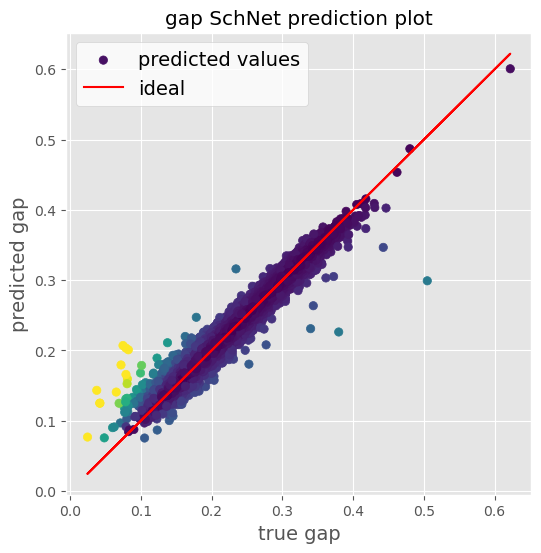

Training scores:
MAE = 0.0054
MSE = 0.0001
RMSE = 0.0072
r^2 = 0.9770


In [9]:
plot_prediction(train_loader, model)

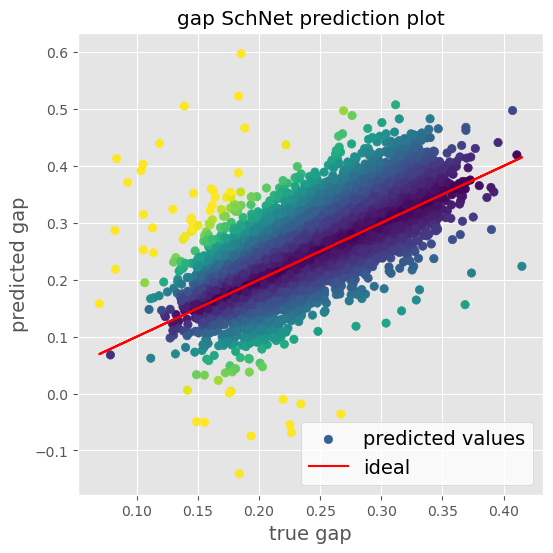

Training scores:
MAE = 0.0389
MSE = 0.0025
RMSE = 0.0504
r^2 = -0.1344


In [23]:
plot_prediction(train_loader, model)

In [7]:
0.0474**2

0.00224676

In [ ]:
results = al_loop_rnd_skorch(
    skorch_model=skorch_schnet,
    n_runs=1,
    save='active_learning/schnet/qm9/al_history_schnet_gap_qm9.csv',
)


Run 1/1  (seed=191664964)


In [ ]:
results_1 = al_loop_rnd_skorch(
    skorch_model=skorch_schnet,
    n_runs=5,
    save='active_learning/schnet/qm9/al_history_schnet_gap_qm9_5.csv',
)

In [66]:
def df_groupby(df):
    '''
    Regroups the AL history df into a new df for plotting.

    Args:
        df : AL history df (pd.DataFrame)
    '''
    df = df.groupby('n_labeled').agg(
        mae_test=('mae_test', 'mean'),   min_mae_test=('mae_test', 'min'),   max_mae_test=('mae_test', 'max'),
        mse_test=('mse_test', 'mean'),   min_mse_test=('mse_test', 'min'),   max_mse_test=('mse_test', 'max'),
        rmse_test=('rmse_test', 'mean'), min_rmse_test=('rmse_test', 'min'), max_rmse_test=('rmse_test', 'max'),
        r2_test=('r2_test', 'mean'),     min_r2_test=('r2_test', 'min'),     max_r2_test=('r2_test', 'max'),
        mae_val=('mae_val', 'mean'),   min_mae_val=('mae_val', 'min'),   max_mae_val=('mae_val', 'max'),
        mse_val=('mse_val', 'mean'),   min_mse_val=('mse_val', 'min'),   max_mse_val=('mse_val', 'max'),
        rmse_val=('rmse_val', 'mean'), min_rmse_val=('rmse_val', 'min'), max_rmse_val=('rmse_val', 'max'),
        r2_val=('r2_val', 'mean'),     min_r2_val=('r2_val', 'min'),     max_r2_val=('r2_val', 'max'),
    ).reset_index()
    return df

def plot_al(dfs, labels, score, save=None, format='pdf'):
    '''
    Plot AL metrics base on labeled samples.

    Args:
        dfs : List of Data Frames modified with df_groupby (list).
        labels : List of AL strategies (list).
        score : Dictionary of metric scores of baseline model (dict).
        save : Save path (str).
        format : Save format (str).
    '''
    metrics = [
        ('mae_test', 'MAE (Eh)'),
        ('rmse_test', 'RMSE (Eh)'),
        ('r2_test', 'R²'),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Generate a color palette dynamically based on the number of dataframes
    cmap = plt.get_cmap('tab10')
    colors = [cmap(i) for i in range(len(dfs))]

    for ax, (key, label) in zip(axes, metrics):
        # Loop through dataframes, labels, and the auto-generated colors
        for df, name, color in zip(dfs, labels, colors):
            ax.plot(
                df['n_labeled'],
                df[key],
                marker='o',
                color=color,
                label=name,
                linewidth=3,
            )
            # ax.fill_between(
            #     df['n_labeled'],
            #     df[f'min_{key}'],
            #     df[f'max_{key}'],
            #     alpha=0.2,
            #     color=color,
            # )

        # Plot the baseline reference line
        # baseline_val = score[key]
        # ax.axhline(
        #     baseline_val,
        #     color='black',
        #     ls='--',
        #     label=f'full = {baseline_val:.4f}',
        #     linewidth=2,
        # )

        
        ax.set_title(label, fontsize=16)
        ax.set_xlabel('Labeled samples', fontsize=16)
        ax.set_ylabel(label, fontsize=16)
        ax.legend(facecolor='white', fontsize=14)
        ax.tick_params(axis='both', labelsize=14)

    plt.tight_layout()
    if save is not None:
        fig.savefig(save, format=format, dpi=300)
    plt.show()

In [88]:
rnd_sample = df_groupby(pd.read_csv('active_learning/schnet/qm9/al_history_schnet_gap_qm9.csv'))

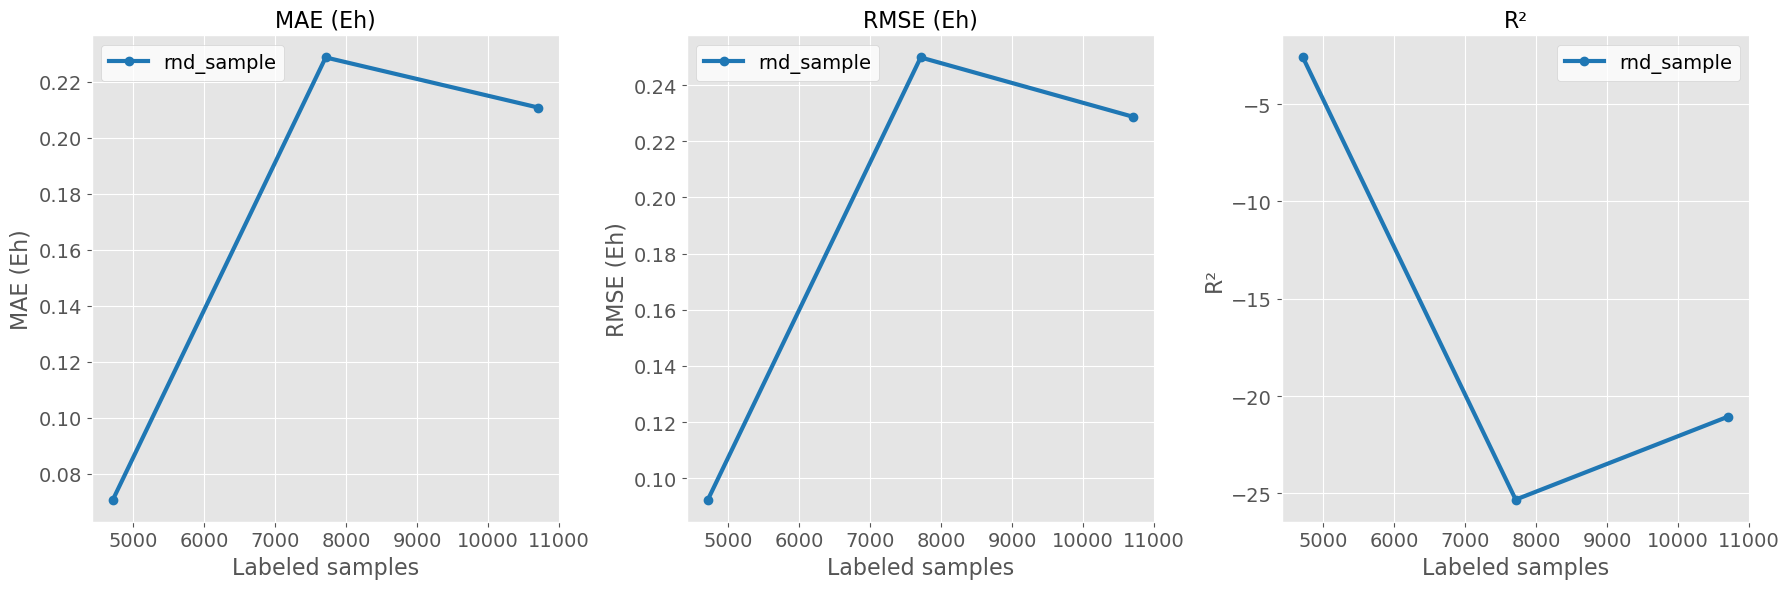

In [89]:
plot_al([rnd_sample], ['rnd_sample'], None)